In [18]:
import pandas as pd

url="D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/Shark-Attack/df_final.csv"
df = pd.read_csv(url)
df

,Date,Season,Year,Type,Country,Source,Age,Sex,State,Location,Fatal Y/N,Activity,Species
0,18-Mar,Spring,2026,Unprovoked,usa,us sun: mendocino coast news:melissa michaelson:,39,M,California,Big River Beach Mendocino County,N,surfing,white shark
1,14-Mar,NaN,2026,Unprovoked,australia,people magazine: kevin mcmurray trackingsharks...,Unknown,F,Western Australia,Exmouth,N,swimming,other
2,10-Mar,NaN,2026,Unprovoked,australia,perth now: kevin mcmurray trackingsharks.com,Unknown,M,Western Australia,Exmouth,N,other,white shark
3,05-Mar,NaN,2026,Unprovoked,australia,news.com.au: abc news: andy currie,Unknown,M,Queensland,Lady Elliott Island,N,snorkeling,other
4,22-Feb,NaN,2026,Unprovoked,new caledonia,johannes marchand: andy currie,55,M,Noumea,Anse Vata near Point Magnin,Y,other,tiger shark
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7077,Unknown,Unknown,Unknown,Unprovoked,australia,"h. taunton; n. bartlett, p. 234",Unknown,M,Western Australia,Roebuck Bay,Y,diving,other
7078,Unknown,Unknown,Unknown,Unprovoked,australia,"h. taunton; n. bartlett, pp. 233-234",Unknown,M,Western Australia,NaN,Y,other,other
7079,Unknown,Unknown,Unknown,Unprovoked,usa,"f. schwartz, p.23; c. creswell, gsaf",Unknown,M,North Carolina,Ocracoke Inlet,Y,swimming,other
7080,Unknown,Unknown,Unknown,Unprovoked,panama,"the sun, 10/20/1938",Unknown,M,Unknown,"Panama Bay 8 N, 79 W",Y,other,other


In [29]:
#column clean --> Fatal Y/N


df["Fatal Y/N"]=df["Fatal Y/N"].replace("UNKNOWN", "Unknown")
df["Fatal Y/N"]=df["Fatal Y/N"].replace(" N", "N")
df["Fatal Y/N"]=df["Fatal Y/N"].replace("n", "N")
df["Fatal Y/N"]=df["Fatal Y/N"].replace("y", "Y")
df["Fatal Y/N"]=df["Fatal Y/N"].replace("N ", "N")
#df["Fatal Y/N"].value_counts()


In [30]:
#column clean --> Activity


df['Activity'] = df['Activity'].astype(str).str.lower().str.strip()
df.loc[df['Activity'].str.contains('surf', na=False), 'Activity'] = 'surfing'
df.loc[df['Activity'].str.contains('swim', na=False), 'Activity'] = 'swimming'
df.loc[df['Activity'].str.contains('fish', na=False), 'Activity'] = 'fishing'
df.loc[df['Activity'].str.contains('dive', na=False), 'Activity'] = 'diving'
df.loc[df['Activity'].str.contains('snork', na=False), 'Activity'] = 'snorkeling'
df.loc[df['Activity'].str.contains('boat', na=False), 'Activity'] = 'boating'
df.loc[df['Activity'].str.contains('kayak', na=False), 'Activity'] = 'kayaking'
df.loc[df['Activity'].str.contains('paddle', na=False), 'Activity'] = 'paddle'
df.loc[df['Activity'].str.contains('wading', na=False), 'Activity'] = 'wading'

common = ['surfing', 'swimming', 'fishing', 'diving', 'snorkeling', 'boating', 'kayaking', 'paddle', 'wading']

df['Activity'] = df['Activity'].apply( lambda x: x if x in common else 'other')
#df


In [31]:

#column clean --> Species


df['Species'] = df['Species'].astype(str).str.lower().str.strip()

#Group shark species
df.loc[df['Species'].str.contains('white', na=False), 'Species'] = 'white shark'
df.loc[df['Species'].str.contains('tiger', na=False), 'Species'] = 'tiger shark'
df.loc[df['Species'].str.contains('bull', na=False), 'Species'] = 'bull shark'
df.loc[df['Species'].str.contains('hammerhead', na=False), 'Species'] = 'hammerhead'
df.loc[df['Species'].str.contains('reef', na=False), 'Species'] = 'reef shark'
df.loc[df['Species'].str.contains('whaler', na=False), 'Species'] = 'whaler shark'
df.loc[df['Species'].str.contains('mako', na=False), 'Species'] = 'mako shark'
#group everything else
common = ['white shark', 'tiger shark', 'bull shark', 'hammerhead', 'reef shark', 'whaler shark', 'mako shark']

df['Species'] = df['Species'].where(df['Species'].isin(common), 'other')


In [32]:
df.to_csv("D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/Shark-Attack/df_final.csv",index=False)

In [33]:
State_df = df.loc[df['State'] == 'Florida']
State_df

,Date,Season,Year,Type,Country,Source,Age,Sex,State,Location,Fatal Y/N,Activity,Species
36,16-Sep,Fall,2012,Unprovoked,usa,"florida today, 9/16/2012",52,M,Florida,"Cocoa Beach, Brevard County",N,surfing,other
40,16-Aug,Summer,2025,Provoked,usa,johannes marchand: kevin mcmurray trackingshar...,Unknown,M,Florida,Cayo Costa Boca Grande,N,fishing,other
47,19-Jul,Summer,2025,Unprovoked,usa,brandyn gartelman: kevin mcmurray trackingshar...,69,M,Florida,Jupiter Inlet off Jupiter Beach Palm Beach County,N,diving,other
48,18-Jul,Summer,2025,Unprovoked,usa,brandyn gartelman: kevin mcmurray trackingshar...,18,M,Florida,New Smyrna Beach,N,surfing,other
51,06-Jul,Summer,2025,Unprovoked,usa,todd smith:kevin mcmurray trackingsharks.com: ...,40,M,Florida,New Smyrna Beach,N,surfing,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6997,Unknown,Unknown,Unknown,Unprovoked,usa,internet,Unknown,M,Florida,"Key West, Monroe County",N,surfing,other
7006,Unknown,Unknown,Unknown,Provoked,usa,"r. skocik, p.176",19,M,Florida,"Riviera Beach, Palm Beach County",N,diving,other
7013,Unknown,Unknown,Unknown,Unprovoked,usa,"w.h. gregg, p.19; l. schultz & m. malin, ...",Unknown,M,Florida,"Mosquito Inlet (Ponce Inlet), Volusia County",Y,other,other
7029,Unknown,Unknown,Unknown,Unprovoked,usa,"v.m. coppleson (1956), p.255; r.f. hutton",Unknown,M,Florida,"Palm Beach, Palm Beach County",N,other,other


In [36]:
#State_df["Location"].value_counts()
#State_df["Fatal Y/N"].value_counts()


In [37]:
#data frame --> Activites vs Seasons


df_Season_Activity=pd.crosstab(State_df["Season"], State_df["Activity"])
df_Season_Activity

Activity,boating,diving,fishing,kayaking,other,paddle,snorkeling,surfing,swimming,wading
Season,,,,,,,,,,
Fall,2,0,21,0,43,0,4,191,44,20
Spring,0,2,29,1,71,1,1,115,39,22
Summer,3,7,39,1,120,0,9,121,70,35
Unknown,0,5,19,0,49,0,1,24,12,4
Winter,0,1,11,0,12,0,0,31,12,2


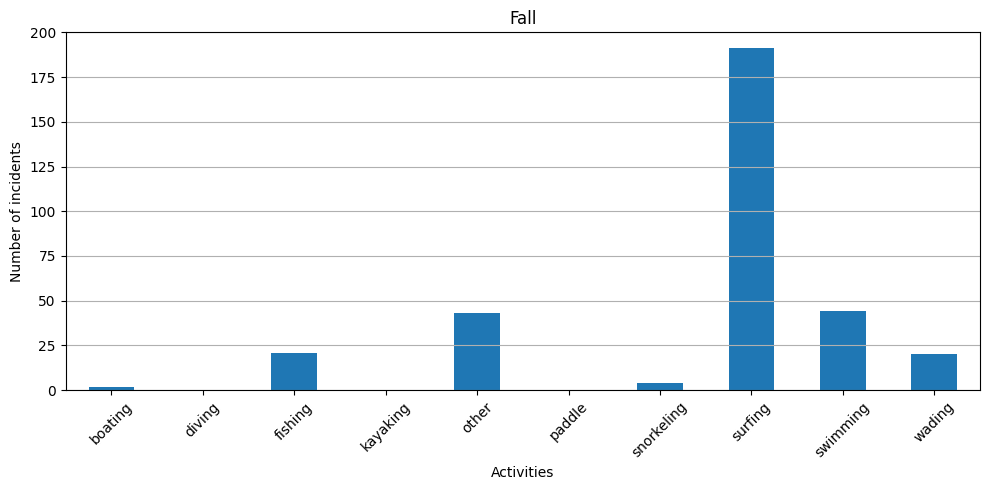

In [38]:
#Bar graph for falle --> Activites VS no. of incidents
import matplotlib.pyplot as plt

df_Season_Activity.loc["Fall"].plot(kind="bar", figsize=(10,5))
plt.ylim(0, 200)
plt.xlabel("Activities")
plt.ylabel("Number of incidents")
plt.title("Fall")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(r"D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/Shark-Attack_backup/Fall.png")
plt.show()

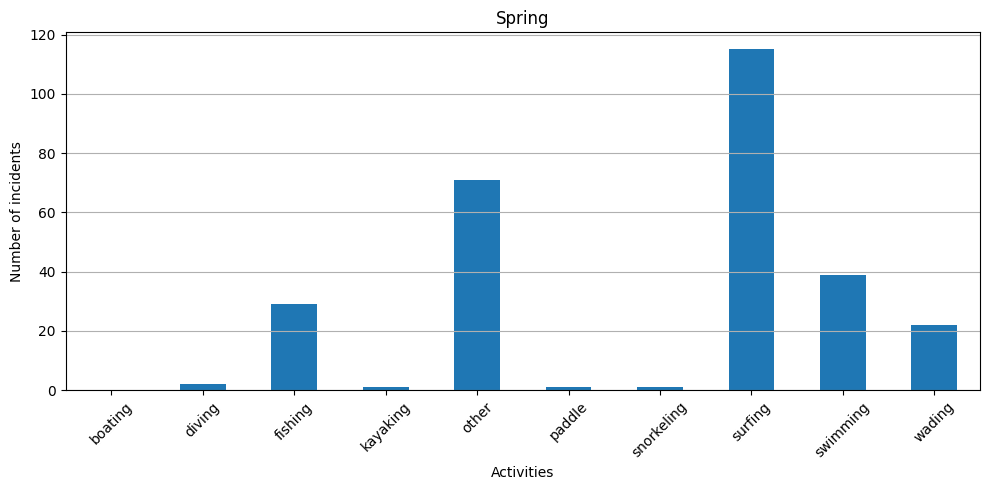

In [39]:
#Bar graph for Spring --> Activites VS no. of incidents



df_Season_Activity.loc["Spring"].plot(kind="bar", figsize=(10,5))
plt.xlabel("Activities")
plt.ylabel("Number of incidents")
plt.title("Spring")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(r"D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/Shark-Attack_backup/Spring.png")
plt.show()

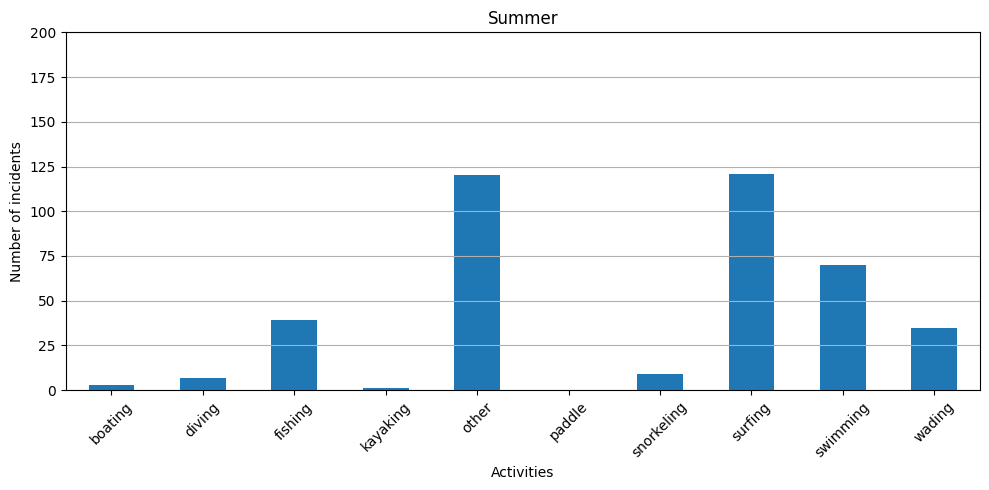

In [40]:
#Bar graph for Summer --> Activites VS no. of incidents


df_Season_Activity.loc["Summer"].plot(kind="bar", figsize=(10,5))
plt.ylim(0, 200)
plt.xlabel("Activities")
plt.ylabel("Number of incidents")
plt.title("Summer")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(r"D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/Shark-Attack_backup/Summer.png")
plt.show()

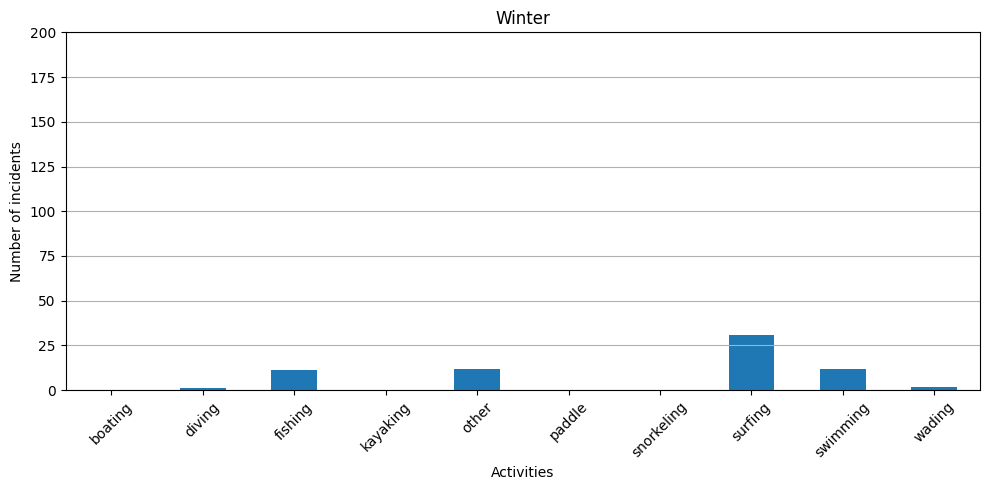

In [41]:
#Bar graph for Winter --> Activites VS no. of incidents



df_Season_Activity.loc["Winter"].plot(kind="bar", figsize=(10,5))
plt.ylim(0, 200)
plt.xlabel("Activities")
plt.ylabel("Number of incidents")
plt.title("Winter")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(r"D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/Shark-Attack_backup/Winter.png")
plt.show()

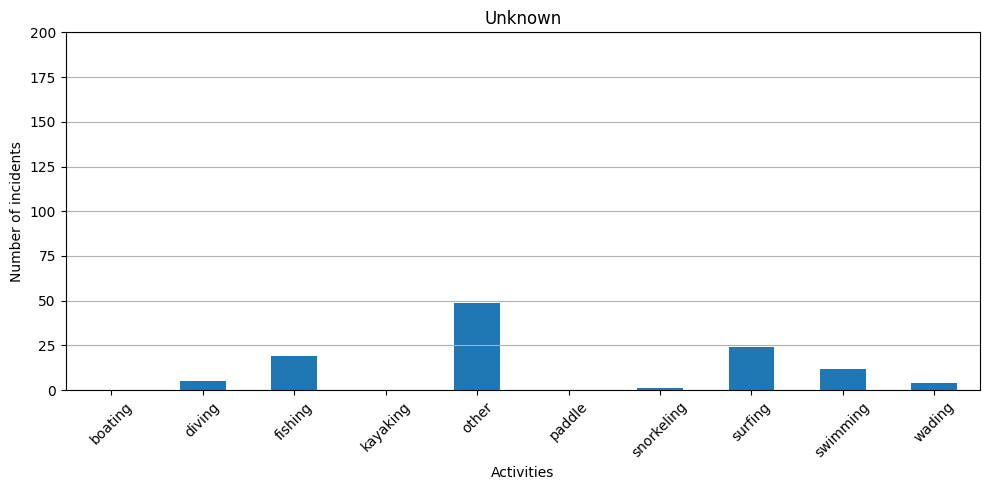

In [42]:
#Bar graph for Unknown --> Activites VS no. of incidents



df_Season_Activity.loc["Unknown"].plot(kind="bar", figsize=(10,5))
plt.ylim(0, 200)
plt.xlabel("Activities")
plt.ylabel("Number of incidents")
plt.title("Unknown")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(r"D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/Shark-Attack_backup/Unknown.png")
plt.show()

In [67]:
#Bar graph for shark attacks --> Fatal and non-fatal VS no. of incidents


df_Species_Fatal=pd.crosstab(State_df["Species"], State_df["Fatal Y/N"]).drop("other")

df_Species_Fatal=df_Species_Fatal.drop("Unknown", axis=1)
df_Species_Fatal

Fatal Y/N,N,Y
Species,,
bull shark,56,4
hammerhead,20,0
mako shark,4,0
reef shark,4,0
tiger shark,13,3
white shark,4,0


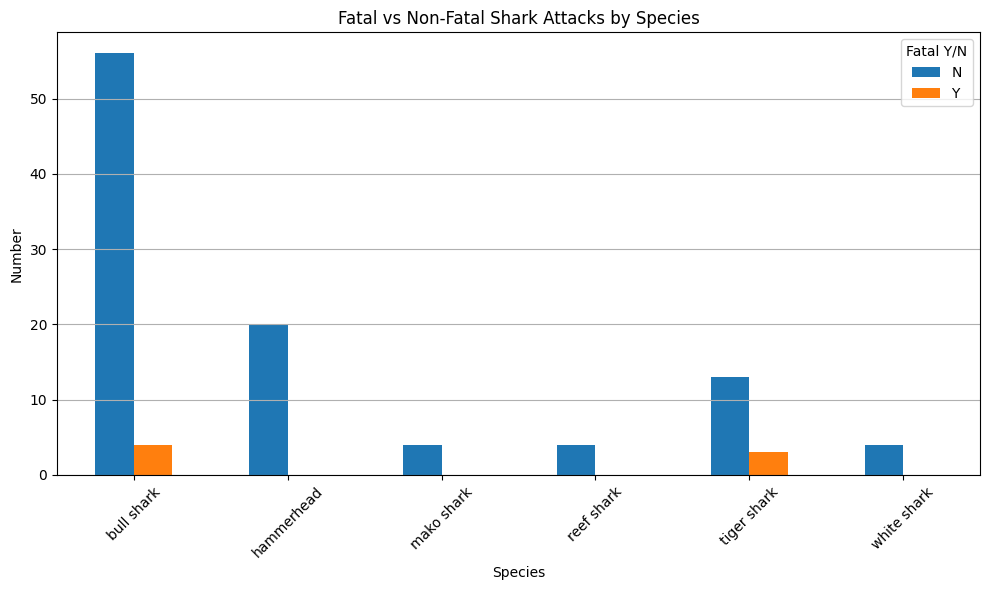

In [72]:
df_Species_Fatal.plot(kind="bar", figsize=(10,6))
plt.xlabel("Species")
plt.ylabel("Number")
plt.title("Fatal vs Non-Fatal Shark Attacks by Species")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(r"D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/Shark-Attack_backup/Fatal_VS_Non-fatal_Attacks.png")
plt.show()

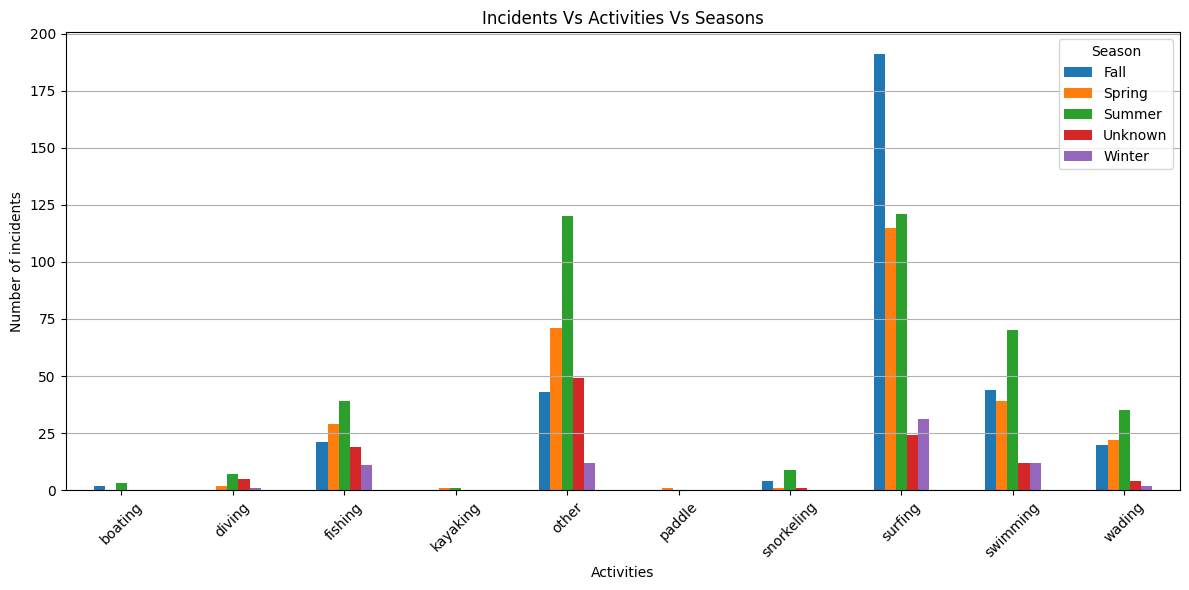

In [76]:
ax = df_Season_Activity.T.plot(kind="bar", figsize=(12,6))

plt.xlabel("Activities")
plt.ylabel("Number of incidents")
plt.title("Incidents Vs Activities Vs Seasons")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(r"D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/Shark-Attack_backup/Incidents Vs Activities Vs Seasons.png")
plt.show()